In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

In [21]:
file_path = r"C:\Users\phunk\OneDrive\Desktop\MyProject\Return Rate\data\0746A520.xlsx"
df = pd.read_excel(file_path)

In [22]:
df.head()

,ID,Category,Day Name,Hour,Days delivered,Status
0,66850940174727,ทั่วไป,Friday,12,2,เซ็นรับ
1,66850940174732,ทั่วไป,Thursday,14,1,เซ็นรับ
2,66850940174746,COD,Tuesday,10,7,ได้รับการคืน
3,66850940174751,COD,Thursday,12,1,เซ็นรับ
4,66850940174765,COD,Friday,15,2,เซ็นรับ


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27717 entries, 0 to 27716
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              27717 non-null  int64
 1   Category        27717 non-null  str  
 2   Day Name        27717 non-null  str  
 3   Hour            27717 non-null  int64
 4   Days delivered  27717 non-null  int64
 5   Status          27717 non-null  str  
dtypes: int64(3), str(3)
memory usage: 1.3 MB


In [24]:
df.describe()

,ID,Hour,Days delivered
count,2.771700e+04,27717.000000,27717.000000
mean,6.754286e+13,13.675795,1.963849
std,1.348738e+13,2.505750,1.481421
min,6.671589e+13,0.000000,0.000000
25%,6.685095e+13,12.000000,1.000000
50%,6.685095e+13,13.000000,2.000000
75%,6.685096e+13,15.000000,2.000000
max,3.300002e+14,23.000000,42.000000


In [25]:
for col in df.select_dtypes(include=["str"]).columns:
    print(f"{col}: {df[col].nunique()}")

Category: 2
Day Name: 7
Status: 2


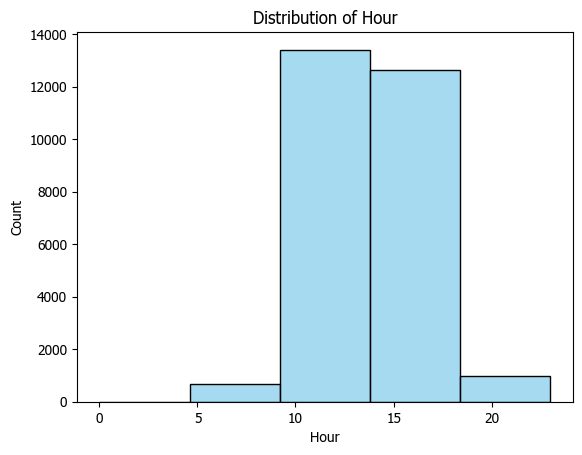

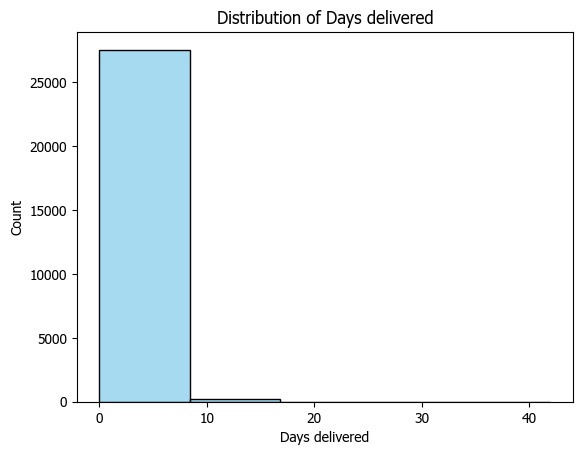

In [26]:
for col in df.select_dtypes(include="number").columns.drop("ID"):
    plt.Figure(figsize=(10, 4))
    sns.histplot(df[col], bins=5, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.show()

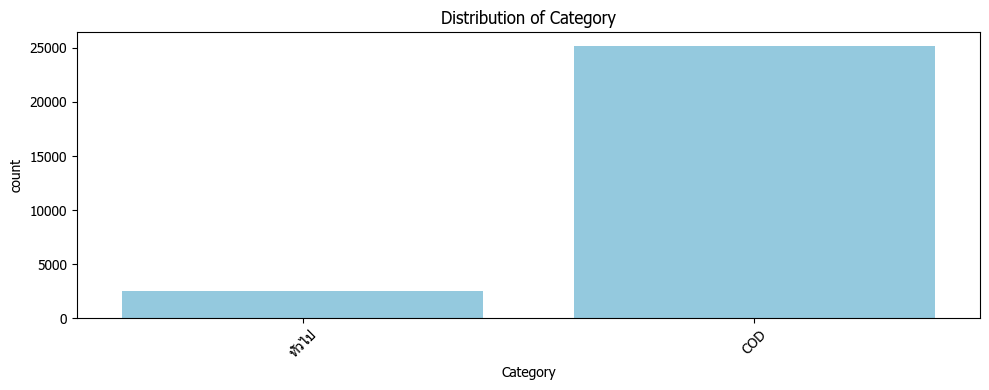

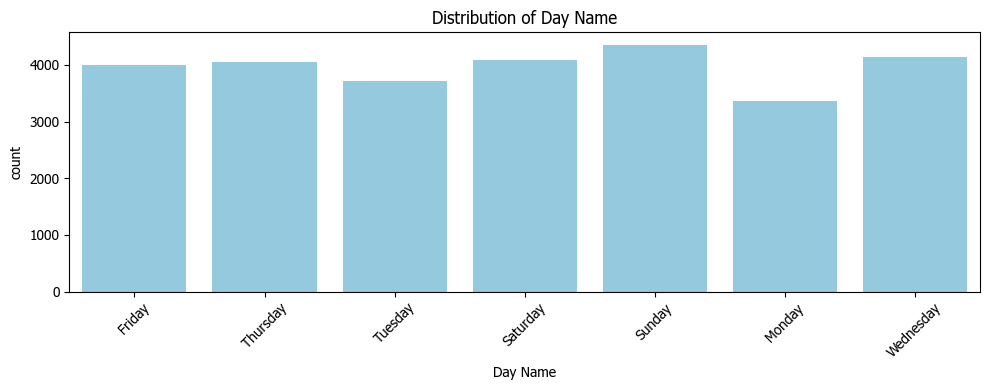

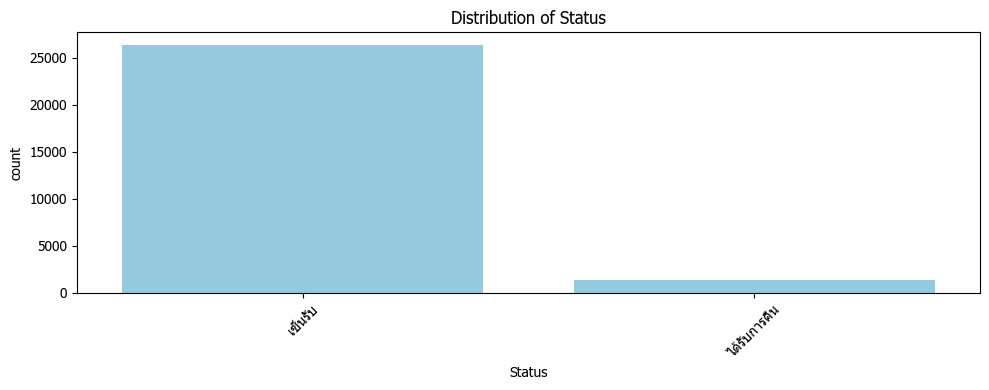

In [27]:
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

for col in df.select_dtypes(include=["object", "category", "string"]).columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [28]:
crosstab = pd.crosstab(df["Day Name"], df["Status"])

chi2, p, dof, expected = stats.chi2_contingency(crosstab)

n = crosstab.sum().sum()
min_dim = min(crosstab.shape) - 1
cramer_v = (chi2 / (n * min_dim)) ** 0.5 if min_dim > 0 else 0

print("--- Contingency Table (Cross Tabulation) ---")
print(crosstab)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramer_v:.4f}")

expected_df = pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns)
low_expected_cells = (expected_df < 5).sum().sum()
total_cells = expected_df.size
pct_low_expected = (low_expected_cells / total_cells) * 100

print("\n--- Assumption Check ---")
print(f"Total Cells: {total_cells}")
print(f"Cells with Expected Value < 5: {low_expected_cells} ({pct_low_expected:.2f}%)")

--- Contingency Table (Cross Tabulation) ---
Status     เซ็นรับ  ได้รับการคืน
Day Name                        
Friday        3845           149
Monday        3094           272
Saturday      3955           138
Sunday        4189           169
Thursday      3888           162
Tuesday       3465           250
Wednesday     3948           193

--- Chi-Square Test Results ---
Chi-Square Statistic : 151.4951
p-value              : 0.0000
Degrees of Freedom   : 6
Cramer's V           : 0.0739

--- Assumption Check ---
Total Cells: 14
Cells with Expected Value < 5: 0 (0.00%)


In [29]:
crosstab = pd.crosstab(df["Hour"], df["Status"])

chi2, p, dof, expected = stats.chi2_contingency(crosstab)

n = crosstab.sum().sum()
min_dim = min(crosstab.shape) - 1
cramer_v = (chi2 / (n * min_dim)) ** 0.5 if min_dim > 0 else 0

print("--- Contingency Table (Cross Tabulation) ---")
print(crosstab)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramer_v:.4f}")

expected_df = pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns)
low_expected_cells = (expected_df < 5).sum().sum()
total_cells = expected_df.size
pct_low_expected = (low_expected_cells / total_cells) * 100

print("\n--- Assumption Check ---")
print(f"Total Cells: {total_cells}")
print(f"Cells with Expected Value < 5: {low_expected_cells} ({pct_low_expected:.2f}%)")

--- Contingency Table (Cross Tabulation) ---
Status  เซ็นรับ  ได้รับการคืน
Hour                         
0             1             1
1             1             0
6             1             0
7            28             9
8            58            95
9           360           129
10         1485           170
11         3086           178
12         3988           138
13         4212           152
14         3813           127
15         3157           145
16         2438            95
17         1694            51
18         1086            23
19          528            13
20          276             5
21          115             2
22           49             0
23            8             0

--- Chi-Square Test Results ---
Chi-Square Statistic : 1858.9835
p-value              : 0.0000
Degrees of Freedom   : 19
Cramer's V           : 0.2590

--- Assumption Check ---
Total Cells: 40
Cells with Expected Value < 5: 9 (22.50%)


In [30]:
def group_time_realistic(hour):
    if hour <= 5:
        return "1. รอบพิเศษ/ค้างคลัง (00:00 - 05:59)"
    elif hour in [6, 7, 8, 9]:
        return "2. ช่วงเช้า (06:00 - 09:59)"
    elif hour in [10, 11, 12]:
        return "3. ช่วงสาย/เที่ยง (10:00 - 12:59)"
    elif hour in [13, 14, 15, 16]:
        return "4. ช่วงบ่าย (13:00 - 16:59)"
    else:  # ตั้งแต่ชั่วโมงที่ 17 เป็นต้นไปจนถึง 23
        return "5. ช่วงเย็น/ค่ำ/ดึก (17:00 - 23:59)"


# แปลงค่าในคอลัมน์เดิมให้กลายเป็นกลุ่มใหม่
df["Time_Grouped"] = df["Hour"].apply(group_time_optimized)

# 2. สร้างตารางไขว้ (Crosstab) จากกลุ่มใหม่
crosstab_new = pd.crosstab(df["Time_Grouped"], df["Status"])

# 3. คำนวณ Chi-Square
chi2, p, dof, expected = stats.chi2_contingency(crosstab_new)

# 4. คำนวณ Cramer's V
n = crosstab_new.sum().sum()
min_dim = min(crosstab_new.shape) - 1
cramer_v = (chi2 / (n * min_dim)) ** 0.5 if min_dim > 0 else 0

# 5. แสดงผลลัพธ์
print("--- New Contingency Table (Grouped) ---")
print(crosstab_new)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramer_v:.4f}")

# 6. ตรวจสอบเงื่อนไข Assumption หลังจัดกลุ่ม
expected_df = pd.DataFrame(
    expected, index=crosstab_new.index, columns=crosstab_new.columns
)
low_expected_cells = (expected_df < 5).sum().sum()
total_cells = expected_df.size
pct_low_expected = (low_expected_cells / total_cells) * 100

print("\n--- Assumption Check ---")
print(f"Total Cells: {total_cells}")
print(
    f"Cells with Expected Value < 5: {low_expected_cells} ({pct_low_expected:.2f}%)"
)

--- New Contingency Table (Grouped) ---
Status                                เซ็นรับ  ได้รับการคืน
Time_Grouped                                               
1. ช่วงเช้าตรู่/เช้า (00:00 - 09:59)      449           234
2. ช่วงสาย/เที่ยง (10:00 - 12:59)        8559           486
3. ช่วงบ่าย (13:00 - 16:59)             13620           519
4. ช่วงเย็น/ค่ำ/ดึก (17:00 - 23:59)      3756            94

--- Chi-Square Test Results ---
Chi-Square Statistic : 1387.5189
p-value              : 0.0000
Degrees of Freedom   : 3
Cramer's V           : 0.2237

--- Assumption Check ---
Total Cells: 8
Cells with Expected Value < 5: 0 (0.00%)


In [ ]:
df.head()